# 11_01.형태소(morphology) 분석 및 WordCloud
- https://konlpy.org/ko/latest/api/konlpy.tag/

## 1.기본 package 설정

### 1.1 그래프 한글 인식 세팅

In [ ]:
# 단어 빈도 및 워드 클라우드에 한글 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

### 1.2 KoNLPY 세팅

In [ ]:
! pip install konlpy

### 1.3 package 설정

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import pandas as pd # pandas 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 전처리
import re                             # 정규식 모듈 임포트

## 3.형태소 처리
from konlpy.tag import Okt

## 4.Word Cloud
import nltk
from collections import Counter
from wordcloud import WordCloud

## 2.데이터 가져오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
tm_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tm.csv', encoding="cp949")
tm_df.head()

,no,구분,전공,본문
0,1,post,전공,코로나19라는 펜데믹 상황에서 \n사람이 모이면 안되는 상황인지라 실험을 진행하는데...
1,2,pre,교양,"3시간이라는 시간이 조금 길 수도 있겠다는 생각이 들지만, 필요한 정보를 많이 얻을..."
2,3,pre,교양,가장 특이하지만 또 가장 이상적인 모습의 교수님이었습니다 나무가 아닌 숲을 보는 수...
3,4,pre,교양,"각자의 생각이 다르고, 대학에 온 이유도 다를텐데, 동영상 ucc제작을 하는 이유를..."
4,5,pre,교양,강사님에 따라 강의 시간이 좋기도 하고 지루하기도 했다.


In [ ]:
#tm_df = tm_df.drop (['Unnamed: 0'], axis=1)
#tm_df.head()

In [ ]:
tm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   no      1998 non-null   int64 
 1   구분      1998 non-null   object
 2   전공      1998 non-null   object
 3   본문      1998 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [ ]:
tm_df['본문'].iloc[0]

'코로나19라는 펜데믹 상황에서 \n사람이 모이면 안되는 상황인지라 실험을 진행하는데 \n있어서 조금 불편함은 있었습니다만 최대한 서로 피해를 주지 않는 선에서 수업을 진행해주신 점이 좋았습니다. \n또한 수업 방식, 과제 제출 등에 대해 불편한 점이 생기면 바로 피드백을 주시고 해결점을 찾아주셔서 좋았고 수업 pdf 파일이 누락되는 일이 생겼을 때 늦더라도 꼭 올려주시는 것이 좋았습니다.  다만 공지가 조금 느리다는 생각이 들었고 공지가 조금 더 빨랐으면 좋았겠다 라는 생각이 들었습니다.\nKC 대학, 교수님, 교수, !!, Zoom 수업'

### 2.2 문서 전처리 및 동음이의어 정리
- 기본적인 문서 전처리 작업을 하고
- 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 정리


In [ ]:
tm_list = []

for i in range(len(tm_df)):
    text = tm_df['본문'].iloc[i]
    text = re.sub('[\x00-\x1F\x7F]', "", text)                # 제어문자[\n, \t] 제거 [[:cntrl:]]
    text = re.sub("[\W]", " ", text)                          # 구두점 등 제거 - 문자와 숫자만 저장
    #text = re.sub("[^\D]", " ", text)                         # 숫자제거
    text = re.sub('(Zoom 수업|Zoom수업|줌 수업)', '줌수업', text)
    text = re.sub('강의', '수업', text)
    tm_list.append(text)

# 2개 단어를 한단어로 통합
# re.sub('(강서 대학교|강서대학|강서 대학)', '강서대학교', text)

# 같은 단어를 한 단어로 변경
# re.sub("공부\\w*", "공부", word)
# re.sub("\\w*\\습니\\w*", "삭제", word)

In [ ]:
tm_list[0]

'코로나19라는 펜데믹 상황에서 사람이 모이면 안되는 상황인지라 실험을 진행하는데 있어서 조금 불편함은 있었습니다만 최대한 서로 피해를 주지 않는 선에서 수업을 진행해주신 점이 좋았습니다  또한 수업 방식  과제 제출 등에 대해 불편한 점이 생기면 바로 피드백을 주시고 해결점을 찾아주셔서 좋았고 수업 pdf 파일이 누락되는 일이 생겼을 때 늦더라도 꼭 올려주시는 것이 좋았습니다   다만 공지가 조금 느리다는 생각이 들었고 공지가 조금 더 빨랐으면 좋았겠다 라는 생각이 들었습니다 KC 대학  교수님  교수      줌수업'

## 3.형태소로 분리 및 불용어제거
- https://konlpy.org/ko/latest/api/konlpy.tag/
- 명사와 동사 추출
- 한단어 삭제
- 동사만 추출은 부록 참고
- 불용어 제거: 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 불용어 제거



In [ ]:
# 명사와 동사추출
okt = Okt()
words_list = []
stop_words = ["하다", "있다", "되어다"]

for i in range(len(tm_list)):
    text = tm_list[i]
    morp = okt.pos(text, stem=True) # stem = 동사 원형 추출

    # 명사와 동사/형용사 추출, 한 글자 단어 삭제, 불용어 제거
    for word, tag in morp:
        if ((tag == 'Noun' or tag == 'Verb' or tag == 'Adjective')
             and (len(word) > 1)
             and (word not in stop_words)):
            words_list.append(word)

words_list

['코로나',
 '펜데믹',
 '상황',
 '사람',
 '모이',
 '안되다',
 '상황',
 '인지',
 '실험',
 '진행',
 '조금',
 '불편하다',
 '최대한',
 '서로',
 '피해',
 '주지',
 '않다',
 '수업',
 '진행',
 '해주다',
 '좋다',
 '또한',
 '수업',
 '방식',
 '과제',
 '제출',
 '대해',
 '불편하다',
 '생기',
 '바로',
 '피드백',
 '주시',
 '해결',
 '찾다',
 '좋다',
 '수업',
 '파일',
 '누락',
 '되다',
 '생기다',
 '늦다',
 '올려주다',
 '좋다',
 '다만',
 '공지',
 '조금',
 '느리다',
 '생각',
 '들다',
 '공지',
 '조금',
 '빨르다',
 '좋다',
 '생각',
 '들다',
 '대학',
 '교수',
 '교수',
 '수업',
 '시간',
 '조금',
 '수도',
 '생각',
 '들다',
 '필요하다',
 '정보',
 '얻다',
 '값지다',
 '시간',
 '이다',
 '가장',
 '특이하다',
 '가장',
 '이상',
 '모습',
 '교수',
 '이다',
 '나무',
 '아니다',
 '보다',
 '수업',
 '같다',
 '학생',
 '이름',
 '외우다',
 '같다',
 '다음',
 '다른',
 '수업',
 '다시',
 '배우다',
 '싶다',
 '각자',
 '생각',
 '다르다',
 '대학',
 '이유',
 '다르다',
 '동영상',
 '제작',
 '이유',
 '자다',
 '모르다',
 '강사',
 '따르다',
 '수업',
 '시간',
 '좋다',
 '기도',
 '지루하다',
 '수업',
 '자료',
 '파워포인트',
 '가시',
 '효과',
 '내지',
 '경우',
 '많다',
 '빼곡',
 '적히다',
 '피피티',
 '자료',
 '수업',
 '집중',
 '요점',
 '흐리다',
 '또한',
 '교수',
 '빠르다',
 '속도',
 '샛길',
 '빠지다',
 '주제가',
 '수업',
 '내용',
 '혼잡하다',
 '토론',


## 4.단어빈도분석

In [ ]:
word_freq = nltk.FreqDist(words_list)
word = word_freq.keys()
freq = list(word_freq.values())
word_count_df = pd.DataFrame([word , freq],
                      index = ["word","freq"]).T
word_count_df.sort_values(["freq"],
                           ascending= False ,
                           inplace=True)
word_count_df[:100]

,word,freq
16,수업,1840
18,좋다,1021
43,교수,797
17,해주다,516
59,학생,501
...,...,...
458,친절하다,46
51,가장,46
46,필요하다,46
786,자세하다,46


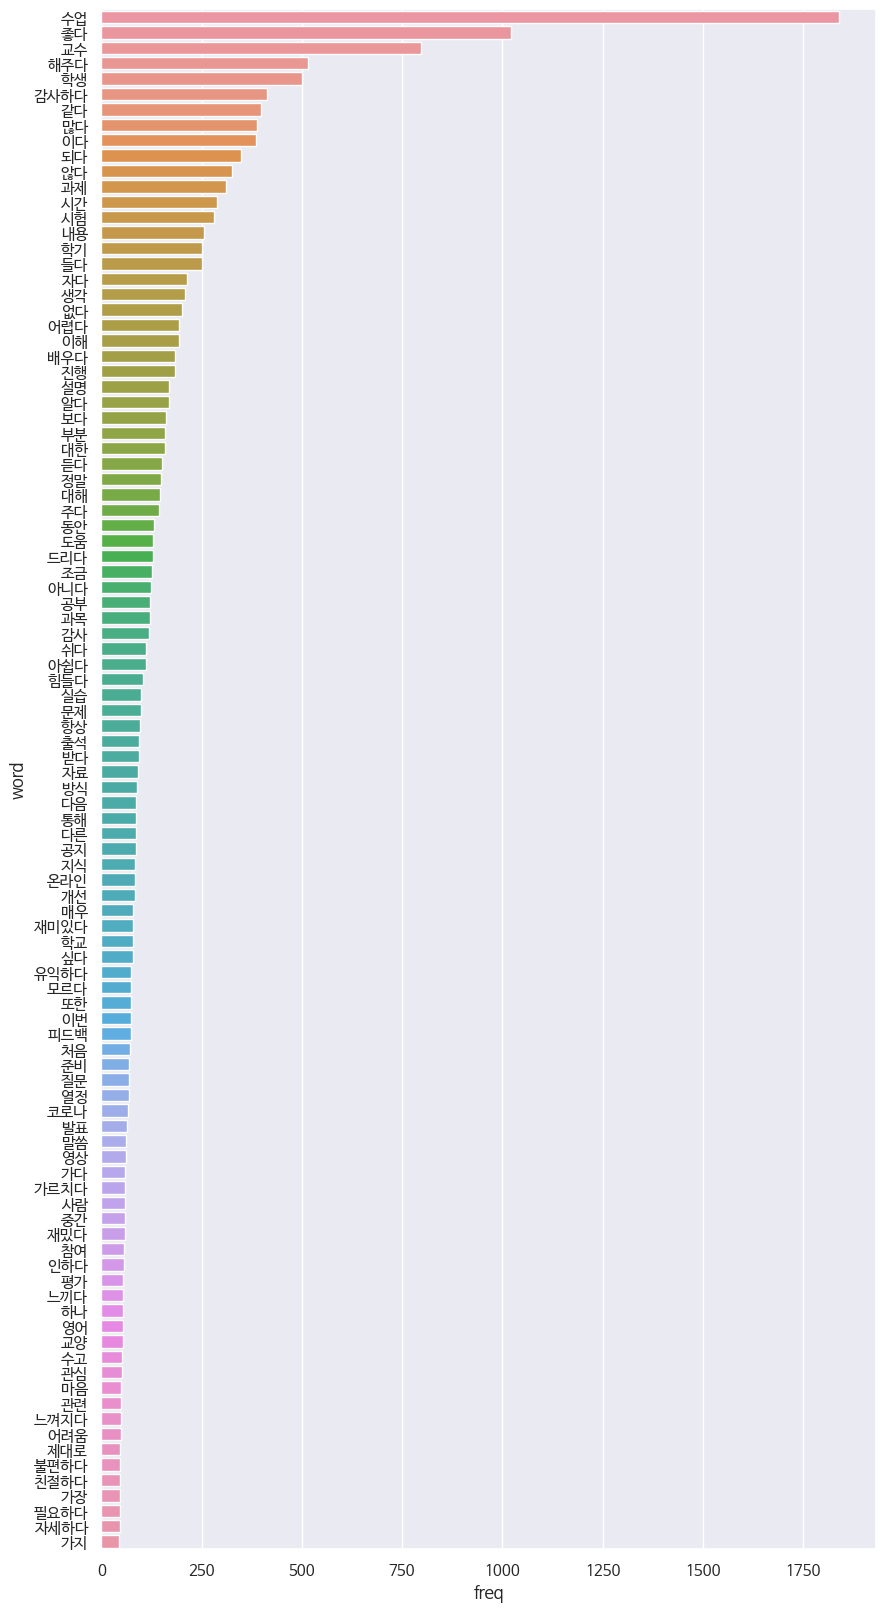

In [ ]:
# 그래프 그리기
# 2회 실행
plt.rc('font', family = 'NanumBarunGothic')

fig, ax = plt.subplots(figsize=(10, 20))
sns.set(font_scale = 1)
ax = sns.barplot(y = "word",
                 x = "freq",
                 data = word_count_df[:100])

plt.show()

## 5.WordColud

In [ ]:
word_counts = Counter(words_list)
word_counts = word_counts.most_common(100)
word_counts

[('수업', 1840),
 ('좋다', 1021),
 ('교수', 797),
 ('해주다', 516),
 ('학생', 501),
 ('감사하다', 412),
 ('같다', 399),
 ('많다', 389),
 ('이다', 387),
 ('되다', 349),
 ('않다', 327),
 ('과제', 311),
 ('시간', 289),
 ('시험', 281),
 ('내용', 257),
 ('학기', 252),
 ('들다', 250),
 ('자다', 214),
 ('생각', 210),
 ('없다', 201),
 ('이해', 195),
 ('어렵다', 195),
 ('배우다', 184),
 ('진행', 183),
 ('설명', 170),
 ('알다', 168),
 ('보다', 162),
 ('부분', 159),
 ('대한', 158),
 ('듣다', 151),
 ('정말', 150),
 ('대해', 146),
 ('주다', 145),
 ('동안', 131),
 ('도움', 130),
 ('드리다', 130),
 ('조금', 127),
 ('아니다', 124),
 ('과목', 122),
 ('공부', 122),
 ('감사', 118),
 ('쉬다', 112),
 ('아쉽다', 111),
 ('힘들다', 104),
 ('실습', 99),
 ('문제', 98),
 ('항상', 96),
 ('출석', 95),
 ('받다', 94),
 ('자료', 92),
 ('방식', 89),
 ('다음', 87),
 ('통해', 87),
 ('공지', 86),
 ('다른', 86),
 ('지식', 84),
 ('온라인', 84),
 ('개선', 83),
 ('매우', 80),
 ('재미있다', 80),
 ('싶다', 79),
 ('학교', 79),
 ('유익하다', 75),
 ('또한', 74),
 ('모르다', 74),
 ('피드백', 73),
 ('이번', 73),
 ('처음', 71),
 ('준비', 70),
 ('질문', 68),
 ('열정', 68),
 ('코로나', 66),
 

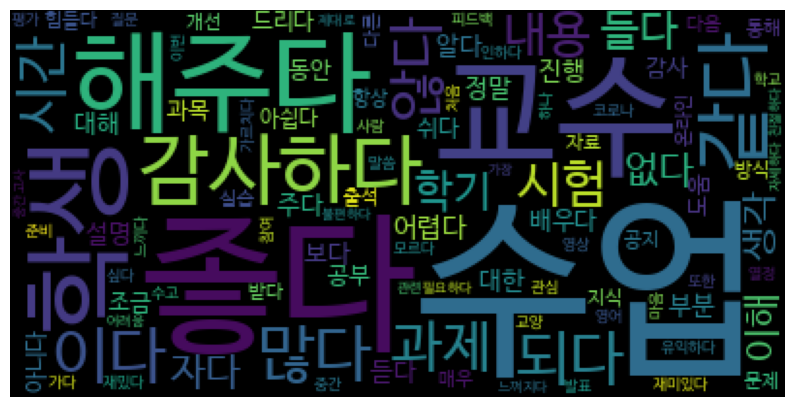

In [ ]:
import matplotlib.font_manager as fm  # 폰트 관련 용도
font_path ='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
#font_name = fm.FontProperties(fname = font_path, size=10).get_name()

wordcloud = WordCloud(font_path = font_path,
                      # background_color='white',
                      #width=800,
                      #height=600,
                      max_font_size=100)

cloud = wordcloud.generate_from_frequencies(dict(word_counts))

plt.figure(figsize=(10, 8))
plt.axis('off')
plt.imshow(cloud)
plt.show()

## 부록

### 부록1.명사만 추출

In [ ]:
okt = Okt()

words_list = [] #이 리스트에 명사를 담을 예정

for i in range(len(tm_list)):
    text = tm_list[i]
    words = okt.nouns(text)
    words = [word for word in words if len(word) > 1]
    words_list.append(words)

words_list

[['코로나',
  '펜데믹',
  '상황',
  '사람',
  '모이',
  '상황',
  '인지',
  '실험',
  '진행',
  '조금',
  '최대한',
  '서로',
  '피해',
  '주지',
  '수업',
  '진행',
  '또한',
  '수업',
  '방식',
  '과제',
  '제출',
  '대해',
  '생기',
  '바로',
  '피드백',
  '주시',
  '해결',
  '수업',
  '파일',
  '누락',
  '다만',
  '공지',
  '조금',
  '생각',
  '공지',
  '조금',
  '생각',
  '대학',
  '교수',
  '교수',
  '수업'],
 ['시간', '조금', '수도', '생각', '정보', '시간'],
 ['가장',
  '가장',
  '이상',
  '모습',
  '교수',
  '나무',
  '수업',
  '학생',
  '이름',
  '다음',
  '다른',
  '수업',
  '다시'],
 ['각자', '생각', '대학', '이유', '동영상', '제작', '이유'],
 ['강사', '강의', '시간', '기도'],
 ['강의',
  '자료',
  '파워포인트',
  '가시',
  '효과',
  '내지',
  '경우',
  '빼곡',
  '피피티',
  '자료',
  '수업',
  '집중',
  '요점',
  '또한',
  '교수',
  '속도',
  '샛길',
  '주제가',
  '수업',
  '내용',
  '토론',
  '역시',
  '분위기',
  '진행',
  '토론',
  '자료',
  '수업',
  '활용'],
 ['시간', '지각', '출석', '영향', '학생', '생각'],
 ['개선',
  '수업',
  '교수',
  '과제',
  '마음대로',
  '그것',
  '매우',
  '과제',
  '내용',
  '또한',
  '과제',
  '또한',
  '중간고사',
  '기말고사',
  '시험',
  '또한',
  '공지',
  '준비',
  '매우',
  '수업',
  '기독교',
  '이해

### 부록2.명사동사 이중 list로 추출
- 토픽모델링에서 사용

In [ ]:
okt = Okt()

words_list = []

for i in range(len(tm_list)):
    text = tm_list[i]
    morp = okt.pos(text, stem=True)                  # stem = 동사 원형 추출
    words = [
        '{}'.format(word) for word, tag in morp      # word 만 추출
        if ((tag in ['Noun'] or tag in ['Verb'])      # 명사와 동사 추출
            and (len(word) > 1))                        # 한 글자 단어 삭제
    ]
    # words = [word for word in words if len(word) > 1]
    words_list.append(words)

words_list

[['기사',
  '내용',
  '요약',
  '금융',
  '추진단',
  '회의',
  '서울',
  '뉴시스',
  '우연',
  '기자',
  '김소영',
  '금융',
  '위원회',
  '부위',
  '원장',
  '해외',
  '환경',
  '사회',
  '지배구조',
  '공시',
  '규제',
  '대응',
  '하다',
  '국내',
  '기업',
  '지원',
  '평가',
  '제도',
  '개선',
  '하다',
  '밝히다',
  '부위',
  '원장',
  '열리다',
  '금융',
  '추진단',
  '회의',
  '공시',
  '평가',
  '투자',
  '각각',
  '가지',
  '방향성',
  '대해',
  '설명',
  '하다',
  '이번',
  '회의',
  '지난',
  '이다',
  '개최',
  '되다',
  '회의',
  '김소영',
  '부위',
  '원장',
  '최근',
  '해외',
  '규율',
  '대상',
  '확대',
  '하다',
  '공시',
  '의무',
  '따르다',
  '국내',
  '기업',
  '간접',
  '영향',
  '받다',
  '예상',
  '되다',
  '하다',
  '실제',
  '국내',
  '기업',
  '상장',
  '돼다',
  '유럽연합',
  '자회사',
  '상장',
  '경우',
  '기업',
  '협력',
  '공급망',
  '해당',
  '하다',
  '경우',
  '국내',
  '기업',
  '회계',
  '연도',
  '단계',
  '규제',
  '준수',
  '하다',
  '필요',
  '미국',
  '상장',
  '국내',
  '기업',
  '규모',
  '따르다',
  '단계',
  '기후',
  '공시',
  '의무',
  '부담',
  '하다',
  '하다',
  '현재',
  '포스코',
  '한국전력',
  '공사',
  '텔레콤',
  '금융',
  '그룹',
  '금융',
  '그룹',
  '개사',
  '공시',
  '의무',
  '

In [ ]:
import itertools
# words_df = sum(words_list, [])                    # 2중 list를 한 개의 list로 통합
words_df = list(itertools.chain(*words_list))